
# Restaurant Data Analysis Project

Internship: Cognifyz Technologies  
Tools Used: Python, Pandas, NumPy, Matplotlib  

# Level 2 – Advanced Data Analysis

This section focuses on deeper analysis of restaurant ratings, cuisine combinations, geographic distribution, and restaurant chains to identify meaningful trends within the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("dataset.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

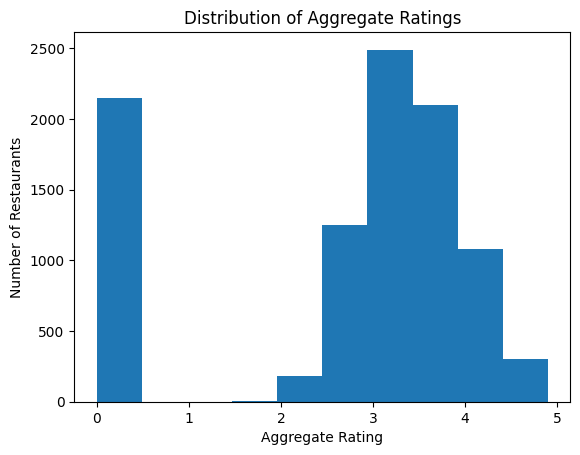

In [7]:
import matplotlib.pyplot as plt


plt.hist(df['Aggregate rating'], bins=10)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.show()

In [8]:
rating_counts = df['Aggregate rating'].value_counts()

most_common_rating = rating_counts.idxmax()

print("Most Common Rating:", most_common_rating)

Most Common Rating: 0.0


Observation:
Restaurants with a rating of 0.0 represent establishments with no customer reviews. 
These entries were excluded to analyze only rated restaurants.

The updated analysis shows the most common rating among actively reviewed restaurants and provides a clearer picture of customer satisfaction trends.

In [11]:
rated_df = df[df['Aggregate rating'] > 0]


In [12]:
rating_counts = rated_df['Aggregate rating'].value_counts()
most_common_rating = rating_counts.idxmax()

print("Most Common Rating:", most_common_rating)

Most Common Rating: 3.2


In [13]:
rated_df = df[df['Aggregate rating'] > 0]

In [14]:
rating_counts = rated_df['Aggregate rating'].value_counts()
most_common_rating = rating_counts.idxmax()

print("Most Common Rating:", most_common_rating)

Most Common Rating: 3.2


## Final Insight – Restaurant Ratings Analysis

The rating distribution shows that most restaurants receive moderate ratings, typically between 3 and 4, indicating generally positive customer experiences.

Restaurants with a rating of 0.0 represent establishments that have not yet received customer reviews. After excluding these unrated entries, the most common rating reflects the typical customer satisfaction level among reviewed restaurants.

The average number of votes indicates the level of customer engagement, showing how frequently customers rate and review restaurants in the dataset.

In [15]:

cuisine_combinations = df['Cuisines'].value_counts()


top_combinations = cuisine_combinations.head(10)

print("Most Common Cuisine Combinations:")
print(top_combinations)

Most Common Cuisine Combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [16]:

cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean()


top_rated_combinations = cuisine_rating.sort_values(ascending=False).head(10)

print("\nCuisine Combinations with Highest Average Ratings:")
print(top_rated_combinations)


Cuisine Combinations with Highest Average Ratings:
Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


In [17]:

rated_df = df[df['Aggregate rating'] > 0]

cuisine_rating = rated_df.groupby('Cuisines')['Aggregate rating'].mean()

top_rated_combinations = cuisine_rating.sort_values(ascending=False).head(10)

print("\nCuisine Combinations with Highest Average Ratings:")
print(top_rated_combinations)


Cuisine Combinations with Highest Average Ratings:
Cuisines
European, German                   4.9
Continental, Indian                4.9
American, Coffee and Tea           4.9
American, BBQ, Sandwich            4.9
Mexican, American, Healthy Food    4.9
Italian, Deli                      4.9
American, Sandwich, Tea            4.9
Burger, Bar Food, Steak            4.9
European, Contemporary             4.9
European, Asian, Indian            4.9
Name: Aggregate rating, dtype: float64


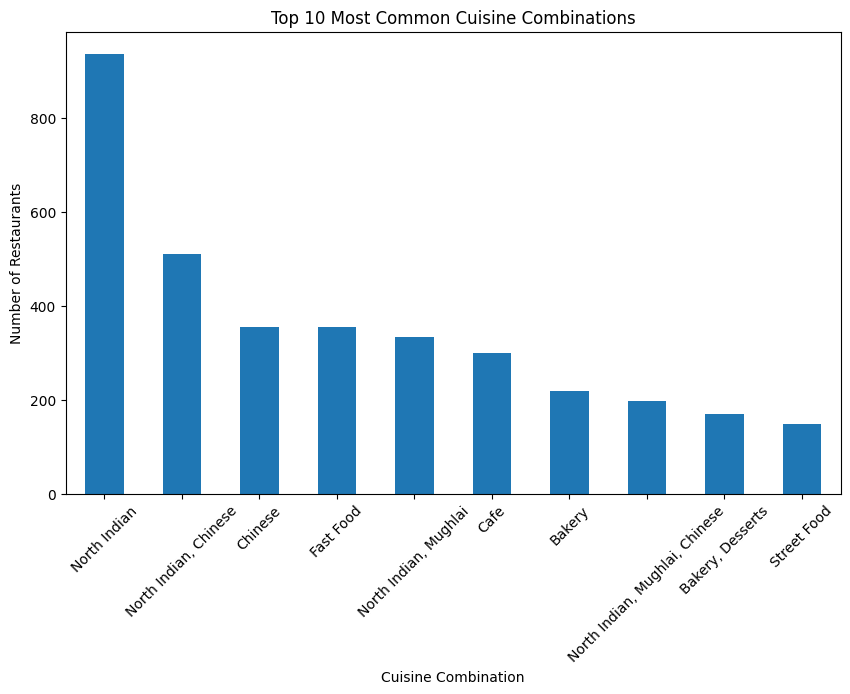

In [18]:
plt.figure(figsize=(10,6))
top_combinations.plot(kind='bar')
plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

## Task 2 – Cuisine Combination Analysis

Observation:
The analysis shows that many restaurants offer multiple cuisines instead of focusing on a single cuisine. 
Certain cuisine combinations appear more frequently in the dataset, indicating popular food pairings that attract customers.

The rating analysis helps identify which cuisine combinations receive higher customer satisfaction. 
Cuisine combinations with higher average ratings may represent restaurants that provide better quality food or more appealing menu diversity.

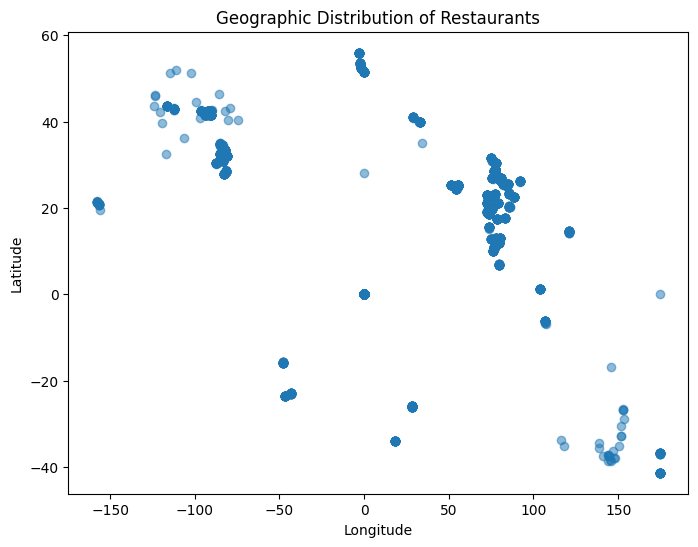

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(df['Longitude'], df['Latitude'], alpha=0.5)

plt.title("Geographic Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## Task 3 – Geographic Analysis

Observation:
The scatter plot visualizes restaurant locations using latitude and longitude coordinates.

Clusters of points indicate areas where many restaurants are concentrated. 
These clusters usually represent urban centers or popular food districts where customer demand is high.

Regions with fewer points suggest areas with lower restaurant density.

In [21]:

restaurant_counts = df['Restaurant Name'].value_counts()

chains = restaurant_counts[restaurant_counts > 1]

print("Restaurant Chains in Dataset:")
print(chains.head(10))

Restaurant Chains in Dataset:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [22]:

chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()

top_chain_ratings = chain_ratings.sort_values(ascending=False).head(10)

print("Top Rated Restaurant Chains:")
print(top_chain_ratings)

Top Rated Restaurant Chains:
Restaurant Name
Braseiro da G??vea               4.9
Sagar Gaire Fast Food            4.9
CakeBee                          4.9
Talaga Sampireun                 4.9
Flat Iron                        4.9
Mainland China Restaurant        4.9
Tresind - Nassima Royal Hotel    4.9
Carnival By Tresind              4.9
Caterspoint                      4.9
Mama's Fish House                4.9
Name: Aggregate rating, dtype: float64


In [23]:

chain_votes = df.groupby('Restaurant Name')['Votes'].mean()

top_chain_votes = chain_votes.sort_values(ascending=False).head(10)

print("Most Popular Restaurant Chains:")
print(top_chain_votes)

Most Popular Restaurant Chains:
Restaurant Name
Toit                10934.0
Hauz Khas Social     7931.0
Peter Cat            7574.0
Big Brewsky          5705.0
The Black Pearl      5385.0
BarBQ                5288.0
Warehouse Cafe       4914.0
Truffles             4841.0
Mocambo              4464.0
Gulati               4373.0
Name: Votes, dtype: float64


## Task 4 – Restaurant Chains Analysis

Observation:
The dataset contains several restaurant chains where the same restaurant name appears in multiple locations.

Analyzing their average ratings helps determine which chains maintain consistent quality across locations.

The number of votes indicates the popularity of each chain, showing which brands receive higher customer engagement and visibility.

## Level 2 – Final Insights

• The rating distribution shows that most restaurants receive moderate ratings, generally between 3 and 4, indicating overall positive customer satisfaction.

• Many restaurants offer multiple cuisine combinations rather than a single cuisine, suggesting that diverse menus help attract a wider customer base.

• Geographic visualization reveals clusters of restaurants in certain areas, indicating regions with high restaurant density and stronger food markets.

• Several restaurant chains appear multiple times in the dataset, showing brand expansion across locations. Some chains also receive higher ratings and votes, indicating strong customer popularity.